The sandbox contains test code and can be safely ignored.

In [12]:
import polars as pl

df1 = pl.DataFrame(
    {
        "id": ["a", "b", "c"],
        "y": ["1", "2", "3"],
    }
)
df2 = pl.DataFrame(
    {
        "id": ["a", "b"],
        "y": ["1", "2"],
        "f_y": ["10", "20"]
    }
)

# df = df1.join(df2, on="id", how="anti")
# print(df)

# df = df2.join(df1, on="id", how="anti")
# print(df)

df = df1.join(df2, on="id", how="left",)
print(df)

df = df.drop([col for col in df.columns if "_right" in col])
print(df)

# df = df2.join(df1, on="id", how="left",)
# print(df)


shape: (3, 4)
┌─────┬─────┬─────────┬──────┐
│ id  ┆ y   ┆ y_right ┆ f_y  │
│ --- ┆ --- ┆ ---     ┆ ---  │
│ str ┆ str ┆ str     ┆ str  │
╞═════╪═════╪═════════╪══════╡
│ a   ┆ 1   ┆ 1       ┆ 10   │
│ b   ┆ 2   ┆ 2       ┆ 20   │
│ c   ┆ 3   ┆ null    ┆ null │
└─────┴─────┴─────────┴──────┘
shape: (3, 3)
┌─────┬─────┬──────┐
│ id  ┆ y   ┆ f_y  │
│ --- ┆ --- ┆ ---  │
│ str ┆ str ┆ str  │
╞═════╪═════╪══════╡
│ a   ┆ 1   ┆ 10   │
│ b   ┆ 2   ┆ 20   │
│ c   ┆ 3   ┆ null │
└─────┴─────┴──────┘


In [2]:
df = pl.read_parquet(source=fc.selected)

# set file name for level2 data file
level2 = os.path.join(fc.selected_path.replace("level1", "level2"), fc.selected_filename)
df = df.with_columns(pl.lit(None, dtype=pl.Int8).alias("flag"))

# select variable
options = df.columns
dropdown = Dropdown(
    value=None, 
    options=options, 
    description="Select variable")
display(dropdown)


Dropdown(description='Select variable', options=('iii', 'zzzztttt', 'tre200s0', 'uor200s0', 'prestas0', 'fa101…

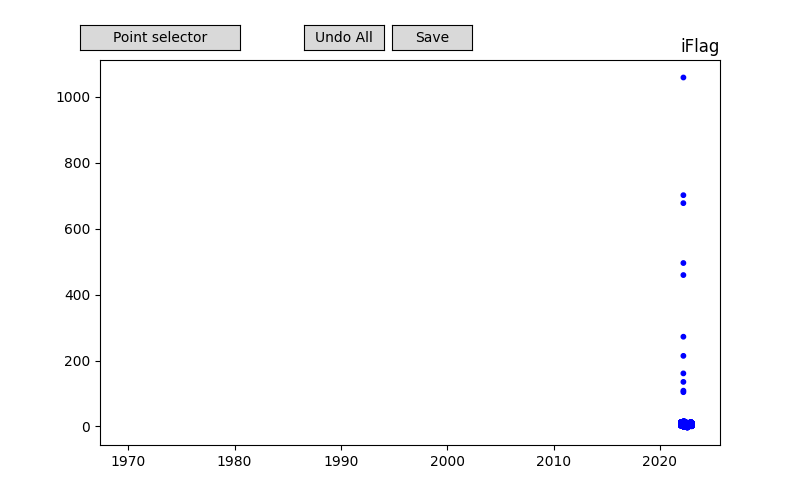

(18265.203125, 426.19) --> (19673.341006944444, 747.86)
The buttons you used were: 1 1


In [7]:
variable = dropdown.value

fig = plt.figure(figsize=(8, 5))
ax = fig.subplots()
ax.set_title('iFlag', loc="right")
pts = ax.scatter(df["dtm"], df[variable], c=["b"]*len(df["dtm"]), s=10, picker=5)

def on_picked_single_point(event):
    """
    event.mouseevent.key : None, Any character, shift, control, win (cf. https://matplotlib.org/stable/users/explain/figure/event_handling.html#event-attributes)
    event.mouseevent.button : 1: left, 2: middle, 3: right
    event.ind : index of point picked. NB: the index is set when the figure is created for the first time, so is unaffected by zooming.
    """
    def update_point(event, pts, flag, color):
        df[event.ind, "flag"] = flag
        pts._facecolors[event.ind, :] = color
        # pts._edgecolors[event.ind, :] = color
        fig.canvas.draw()
        return

    # if event.mouseevent.button==1:
    if event.mouseevent.key=="shift":
        update_point(event, pts, None, (0,0,1,1))    # unflag a data point
    elif event.mouseevent.key=="1":
        update_point(event, pts,  1, (1,0,1,1))
    elif event.mouseevent.key=="2":
        update_point(event, pts, 2, (0,1,0,1))
    elif event.mouseevent.key=="3":
        update_point(event, pts, 3, (1,1,1,1))

def on_clicked_undo_all(event):
    print("on_clicked_undo_all")

def on_clicked_save(event):
    global df, level2
    print("on_clicked_save")
    print(f"variable: {dropdown.value}")
    df = df.rename({"flag": f"{dropdown.value}_flag"})
    if os.path.exists(level2):
        if input("File exists. Okay to over-write (y/n)?") == "y":
           df.write_parquet(level2)

# Function to be called when rectangle selection is done
def onselect(eclick, erelease):
    global ind, x1, x2
    # ind = np.arange(len(x))[(x > min(eclick.xdata, erelease.xdata)) &
    #                          (x < max(eclick.xdata, erelease.xdata)) &
    #                          (y > min(eclick.ydata, erelease.ydata)) &
    #                          (y < max(eclick.ydata, erelease.ydata))]
    # x1, y1 = pl.datetime(matplotlib.dates.num2date(eclick.xdata, tz="UTC")), eclick.ydata
    # x2, y2 = matplotlib.dates.num2date(erelease.xdata, tz="UTC"), erelease.ydata
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata
    print(f"({x1}, {y1:3.2f}) --> ({x2}, {y2:3.2f})")
    # print(f"({x1:3.2f}, {y1:3.2f}) --> ({x2:3.2f}, {y2:3.2f})")
    print(f"The buttons you used were: {eclick.button} {erelease.button}")
    # df2 = df.filter((pl.col("dtm").to_numpy() > min(x1, x2)) & (pl.col("dtm").to_numpy() < max(x1, x2)))
    # ind = np.arange(len(df))[(df["dtm"] > min(x1, x2)) &
    #                          (df["dtm"] < max(x1, x2)) &
    #                          (df[variable] > min(eclick.ydata, erelease.ydata)) &
    #                          (df[variable] < max(eclick.ydata, erelease.ydata))]
    # print('Selected points indices:', ind)

# Function to toggle the RectangleSelector
def toggle_selector(event):
    if toggle_selector.RS.active:
        toggle_selector.RS.set_active(False)
        button.label.set_text('Point selector')
    else:
        toggle_selector.RS.set_active(True)
        button.label.set_text('Rectangle selector')

toggle_selector.RS = RectangleSelector(ax, onselect, useblit=True, button=[1, 3], minspanx=5, minspany=5, spancoords='pixels')


# create buttons for interaction
button = Button(plt.axes([0.1, .9, 0.2, 0.05]), 'Point selector')
button.on_clicked(toggle_selector)
# button_select_variable = Button(plt.axes([0.22, .9, 0.15, 0.05]), 'Select variable')
# button_select_variable.set_active(False)
# button_select_variable.on_clicked(on_clicked_select_variable)
button_undo_all = Button(plt.axes([0.38, .9, 0.1, 0.05]), 'Undo All')
button_undo_all.on_clicked(on_clicked_undo_all)
button_save = Button(plt.axes([0.49, .9, 0.1, 0.05]), 'Save')
button_save.on_clicked(on_clicked_save)

# connect to figure and enable pick event
cid_picked = fig.canvas.mpl_connect('pick_event', on_picked_single_point)

# connect to figure and enable rectangle select event
# cid_rectangle = fig.canvas.mpl_connect('key_press_event', toggle_selector)

plt.show()

In [17]:
# x1, y1 = pl.datetime(matplotlib.dates.num2date(eclick.xdata, tz="UTC")), eclick.ydata
# x2, y2 = matplotlib.dates.num2date(erelease.xdata, tz="UTC"), erelease.ydata
d1 = matplotlib.dates.num2date(x1, tz="UTC")
d2 = df["dtm"][1]

In [ ]:
# %matplotlib ipympl 
# import os
# import numpy as np
# import polars as pl
# import matplotlib.pyplot as plt
# from matplotlib.path import Path
# from matplotlib.widgets import Button, RectangleSelector, LassoSelector
# import datetime as dt


# # class SelectFromCollection:
# #     """
# #     Select indices from a matplotlib collection using `LassoSelector`.

# #     Selected indices are saved in the `ind` attribute. This tool fades out the
# #     points that are not part of the selection (i.e., reduces their alpha
# #     values). If your collection has alpha < 1, this tool will permanently
# #     alter the alpha values.

# #     Note that this tool selects collection objects based on their *origins*
# #     (i.e., `offsets`).

# #     Parameters
# #     ----------
# #     ax : `~matplotlib.axes.Axes`
# #         Axes to interact with.
# #     collection : `matplotlib.collections.Collection` subclass
# #         Collection you want to select from.
# #     alpha_other : 0 <= float <= 1
# #         To highlight a selection, this tool sets all selected points to an
# #         alpha value of 1 and non-selected points to *alpha_other*.
# #     """

# #     def __init__(self, ax, collection, alpha_other=0.3):
# #         self.canvas = ax.figure.canvas
# #         self.collection = collection
# #         self.alpha_other = alpha_other

# #         self.xys = collection.get_offsets()
# #         self.Npts = len(self.xys)

# #         # Ensure that we have separate colors for each object
# #         self.fc = collection.get_facecolors()
# #         if len(self.fc) == 0:
# #             raise ValueError('Collection must have a facecolor')
# #         elif len(self.fc) == 1:
# #             self.fc = np.tile(self.fc, (self.Npts, 1))

# #         self.lasso = LassoSelector(ax, onselect=self.onselect)
# #         self.ind = []

# #     def onselect(self, verts):
# #         path = Path(verts)
# #         self.ind = np.nonzero(path.contains_points(self.xys))[0]
# #         self.fc[:, -1] = self.alpha_other
# #         self.fc[self.ind, -1] = 1
# #         self.collection.set_facecolors(self.fc)
# #         self.canvas.draw_idle()

# #     def disconnect(self):
# #         self.lasso.disconnect_events()
# #         self.fc[:, -1] = 1
# #         self.collection.set_facecolors(self.fc)
# #         self.canvas.draw_idle()

# def on_picked_single_point(event):
#     """
#     event.mouseevent.key : None, Any character, shift, control, win (cf. https://matplotlib.org/stable/users/explain/figure/event_handling.html#event-attributes)
#     event.mouseevent.button : 1: left, 2: middle, 3: right
#     event.ind : index of point picked. NB: the index is set when the figure is created for the first time, so is unaffected by zooming.
#     """
#     def update_point(event, flag, color):
#         df[event.ind, "flag"] = flag
#         pts._facecolors[event.ind, :] = color
#         # pts._edgecolors[event.ind, :] = color
#         fig.canvas.draw()
#         return

#     # if event.mouseevent.button==1:
#     if event.mouseevent.key=="shift":
#         update_point(event, None, (0,0,1,1))    # unflag a data point
#     elif event.mouseevent.key=="1":
#         update_point(event, 1, (1,0,1,1))
#     elif event.mouseevent.key=="2":
#         update_point(event, 2, (0,1,0,1))
#     elif event.mouseevent.key=="3":
#         update_point(event, 3, (1,1,1,1))

# def on_clicked_load_data(event):
#     print("on_clicked_load_data")

# def on_clicked_undo_all(event):
#     print("on_clicked_undo_all")

# def on_clicked_save(event):
#     print("on_clicked_save")

# def on_rectangle_selected(eclick, erelease):
#     x1, y1 = eclick.xdata, eclick.ydata
#     x2, y2 = erelease.xdata, erelease.ydata
#     print(f"({x1:3.2f}, {y1:3.2f}) --> ({x2:3.2f}, {y2:3.2f})")
#     print(f"The buttons you used were: {eclick.button} {erelease.button}")

# def on_lasso_selection_complete(event):
#     # print(event)
#     # print(df[selector.ind])
    
#     def update_selection(event, flag, color):
#         print(df[selector.ind])
#         # df[event.ind, "flag"] = flag
#         # sc._facecolors[event.ind, :] = color
#         # fig.canvas.draw()
#         return

#     # if event.mouseevent.button==1:
#     if event.mouseevent.key=="shift":
#         update_selection(event, None, (0,0,1,1))    # unflag a data point
#     elif event.mouseevent.key=="1":
#         update_selection(event, 1, (1,0,1,1))
#     elif event.mouseevent.key=="2":
#         update_selection(event, 2, (0,1,0,1))
#     elif event.mouseevent.key=="3":
#         update_selection(event, 3, (1,1,1,1))

#     # if event.button == 3:
#     #     print("Selected points:")
        
#         # selector.disconnect()
#         # ax.set_title("")
#         # fig.canvas.draw()


# # import tkFileDialog as fd
# # fname = fd.askopenfilename(initialdir='c:/temp')
# # fname
# source = os.path.join(os.getcwd(), "data/level1/2022/vrxa00.parquet")
# variable = "tre200s0"
# df = pl.read_parquet(source=source)
# df = df.with_columns(pl.lit(None, dtype=pl.Int8).alias("flag"))

# fig = plt.figure(figsize=(8, 5))
# ax = fig.subplots()

# ax.set_title('iFlag', loc="right")
# pts = ax.scatter(df["dtm"], df[variable], c=["b"]*len(df["dtm"]), s=10,
#                 picker=5)  # 10 points tolerance

# # create buttons for interaction
# button_load_data = Button(plt.axes([0.1, .9, 0.1, 0.05]), 'Load')
# button_load_data.on_clicked(on_clicked_load_data)
# # button_flag_all = Button(plt.axes([0.22, .9, 0.1, 0.05]), 'Flag All')
# # button_flag_all.on_clicked(on_clicked_flag_all)
# button_undo_all = Button(plt.axes([0.33, .9, 0.1, 0.05]), 'Undo All')
# button_undo_all.on_clicked(on_clicked_undo_all)
# button_save = Button(plt.axes([0.44, .9, 0.1, 0.05]), 'Save')
# button_save.on_clicked(on_clicked_save)
# # selector = SelectFromCollection(ax, pts)
# # props = dict(facecolor='blue', alpha=0.5)
# # rectangle_flag_all = RectangleSelector(ax, on_rectangle_selected,
# #         useblit=True,
# #         button=[1, 3], minspanx=5, minspany=5,
# #         spancoords='pixels',interactive=True, props=props)

# # connect to figure and enable pick event
# cid = fig.canvas.mpl_connect('pick_event', on_picked_single_point)

# # display widgets
# # display(file_upload)

# # fig.canvas.mpl_connect("key_press_event", accept)
# # fig.canvas.mpl_connect("button_release_event", on_lasso_selection_complete)

# plt.show()
# # rectangle_flag_all.set_active(True)
# # rectangle_flag_all.add_state("center")


In [ ]:
# import os
# import polars as pl
# from processing.meteo import Meteo
# met = Meteo()

# source = os.path.join(os.getcwd(), "data/level1/2022/vrxa00.parquet")
# df = pl.read_parquet(source)
# display(df.describe())

# variable = "ta2200s0"
# variable = "fkl010z0"
# variable = "fa1010z0"
# variable = "fkl010z1"
# variable = "tre200s0"
# met.plot_data(df, variable=variable)

In [ ]:
# # Automatic flagging of outliers
# import numpy as np
# import pandas as pd
# from sklearn.neighbors import LocalOutlierFactor
# import matplotlib.pyplot as plt

# # Generate a sample time series temperature dataset
# np.random.seed(42)
# timestamps = pd.date_range(start="2024-01-01", end="2024-01-31", freq="H")
# temperatures = np.random.normal(loc=20, scale=5, size=len(timestamps))

# # Introduce some outliers
# temperatures[10] = 40
# temperatures[20] = 5

# # Create a DataFrame
# df = pd.DataFrame({"Timestamp": timestamps, "Temperature": temperatures})

# # Extract temperature values as a 1D array
# temperature_values = df["Temperature"].values.reshape(-1, 1)

# # Use the Sub-LOF method to detect outliers
# lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
# outliers = lof.fit_predict(temperature_values)

# # Add the outlier labels to the DataFrame
# df["Outlier"] = outliers

# # Plot the time series with outliers highlighted
# plt.figure(figsize=(10, 6))
# plt.plot(df["Timestamp"], df["Temperature"], label="Temperature")
# plt.scatter(df["Timestamp"][df["Outlier"] == -1], df["Temperature"][df["Outlier"] == -1], color='red', label="Outliers")
# plt.title("Time Series with Outliers Detected using Sub-LOF")
# plt.xlabel("Timestamp")
# plt.ylabel("Temperature")
# plt.legend()
# plt.show()


In [ ]:
# import os
# source = os.path.join("/product_data/data/pay/Kenya/MKN/incoming/g2401")
# by = "month" # "year"
# years = ["20{:2d}".format(yy) for yy in range(20, 30, 1)]
# months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

# for year in years:
#     if by=="month":
#         for month in months:
#             base = os.path.join(source, year, month)        
#             if os.path.exists(base):
#                 for root, dirs, files in os.walk(base):
#                     print(f"base: {base}")                
#                     print(f"root: {root}")
#                     print(f"files: {len(files)}")
#     elif by=="year":
#         base = os.path.join(source, year)        
#         if os.path.exists(base):
#             for root, dirs, files in os.walk(base):
#                 print(f"base: {base}")                
#                 print(f"root: {root}")
#                 print(f"files: {len(files)}")


In [ ]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )

In [ ]:
# # Example of using ECOD for outlier detection
# # Author: Yue Zhao <zhaoy@cmu.edu>
# # License: BSD 2 clause
# # adapted from: https://github.com/yzhao062/pyod/blob/master/examples/ecod_example.py

# from __future__ import division
# from __future__ import print_function

# import os
# import sys

# # temporary solution for relative imports in case pyod is not installed
# # if pyod is installed, no need to use the following line
# # sys.path.append(
# #     os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

# from pyod.models.ecod import ECOD
# from pyod.utils.data import generate_data
# from pyod.utils.data import evaluate_print
# from pyod.utils.example import visualize

# contamination = 0.1  # percentage of outliers
# n_train = 200  # number of training points
# n_test = 100  # number of testing points

# # Generate sample data
# X_train, X_test, y_train, y_test = \
#     generate_data(n_train=n_train,
#                     n_test=n_test,
#                     n_features=2,
#                     contamination=contamination,
#                     random_state=42)

# # train ECOD detector
# clf_name = 'ECOD'
# # clf = ECOD()

# # you could try parallel version as well.
# clf = ECOD(n_jobs=2)
# clf.fit(X_train)

# # get the prediction labels and outlier scores of the training data
# y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
# y_train_scores = clf.decision_scores_  # raw outlier scores

# # get the prediction on the test data
# y_test_pred = clf.predict(X_test)  # outlier labels (0 or 1)
# y_test_scores = clf.decision_function(X_test)  # outlier scores

# # evaluate and print the results
# print("\nOn Training Data:")
# evaluate_print(clf_name, y_train, y_train_scores)
# print("\nOn Test Data:")
# evaluate_print(clf_name, y_test, y_test_scores)

# # visualize the results
# visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred,
#             y_test_pred, show_figure=True, save_figure=False)